<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Simulated_Laser_Scan_Path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_706/2976278608.py:54: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('X Position ($\mu m$)')
/tmp/ipykernel_706/2976278608.py:55: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Y Position ($\mu m$)')


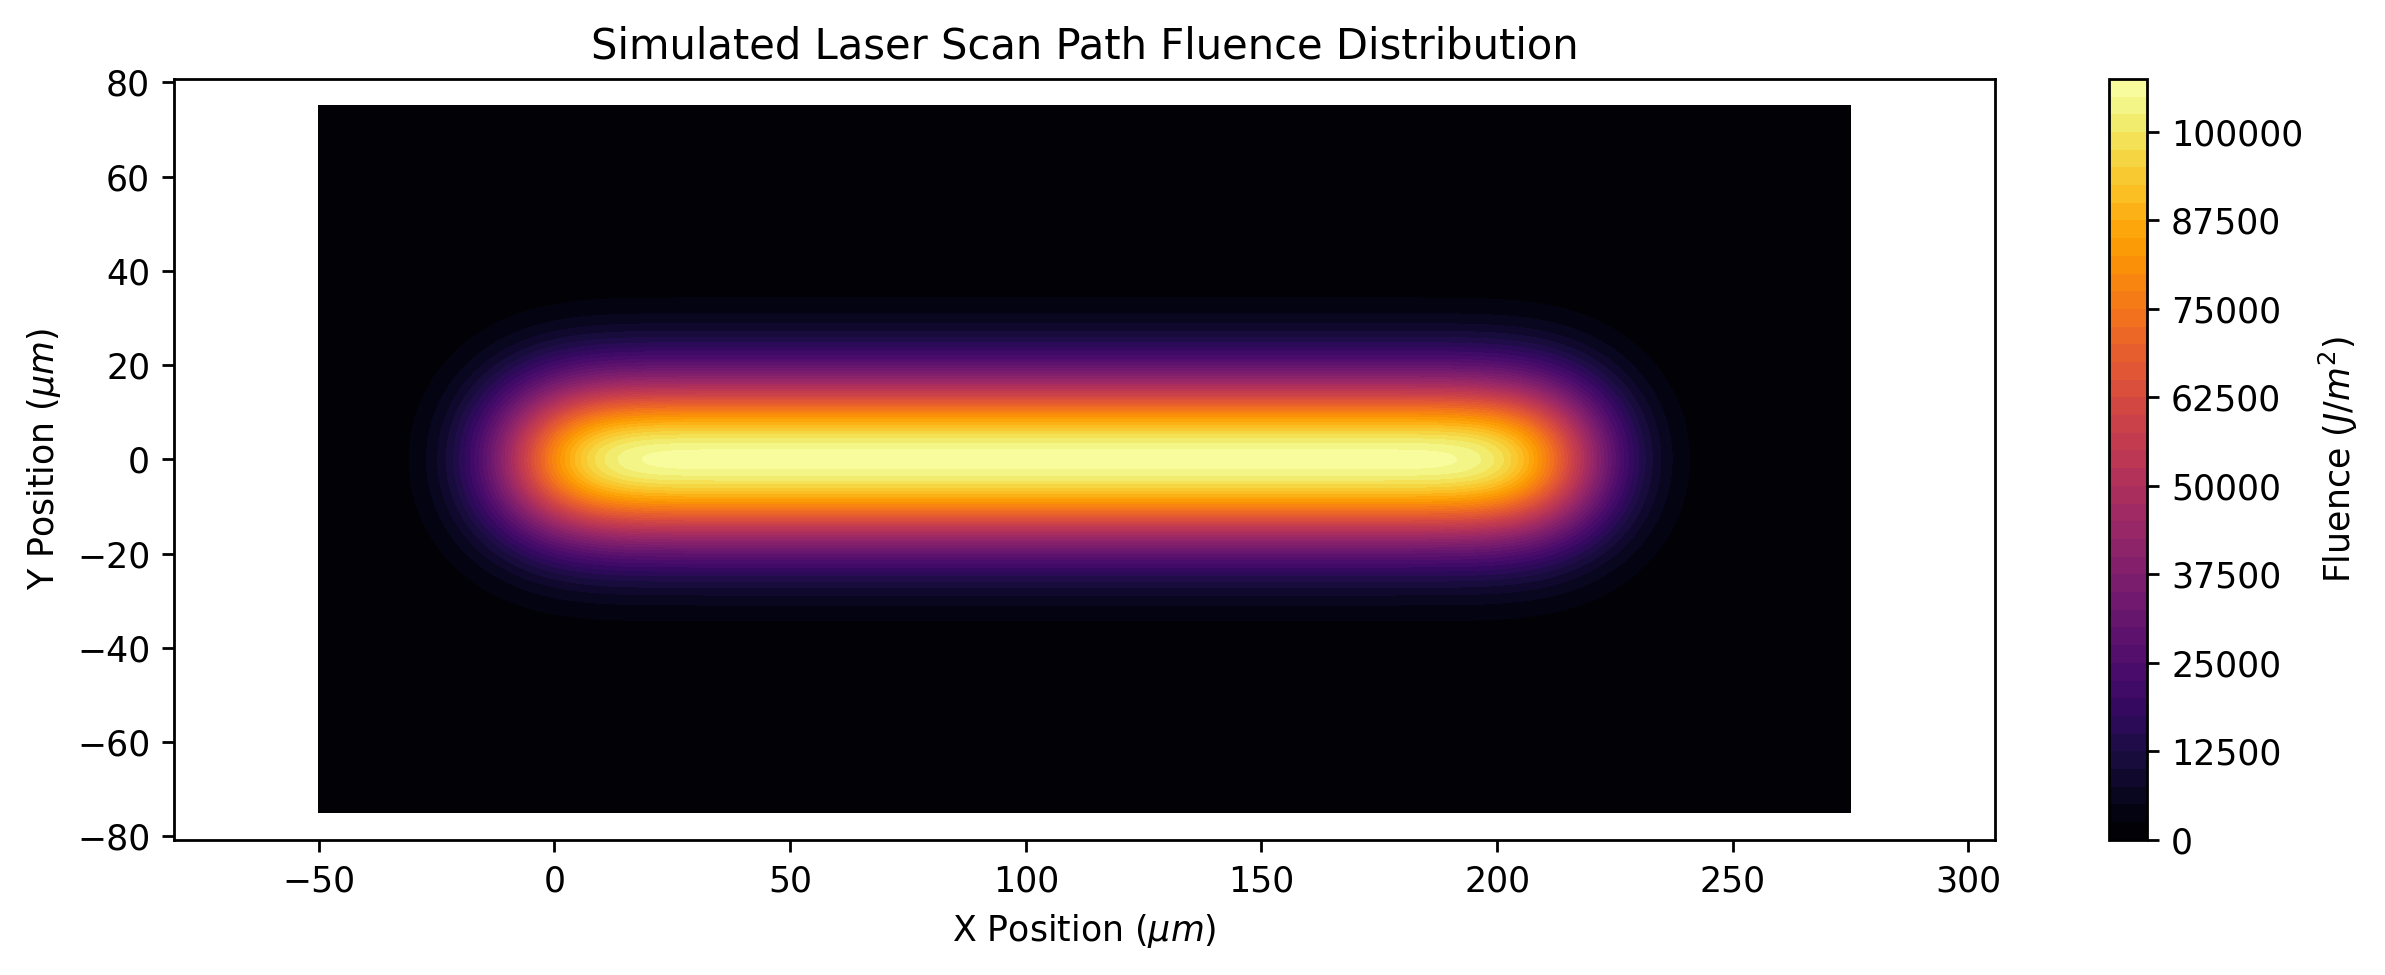

In [1]:
"""
Laser Ablation Scan Path Simulator.

This script visualizes the cumulative energy density (fluence)
deposited on a metal surface by a scanning Gaussian laser beam.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
PULSE_ENERGY = 50e-6      # Energy per pulse in Joules (J)
SPOT_RADIUS = 25e-6       # Laser beam waist (w0) in meters (m)
PULSE_COUNT = 15          # Number of pulses in the scan line
OVERLAP_RATIO = 0.7       # Percent overlap between consecutive pulses (0 to 1)
RESOLUTION = 500          # Grid resolution for the plot
# ---------------------

def gaussian_2d(x, y, x0, y0, w0, energy):
    """
    Calculate the fluence of a single Gaussian pulse.

    Parameters:
        x, y: Grid coordinates.
        x0, y0: Pulse center coordinates.
        w0: Beam waist radius.
        energy: Pulse energy.
    """
    # Peak fluence F0 = 2 * E / (pi * w0^2)
    f0 = (2 * energy) / (np.pi * w0**2)
    return f0 * np.exp(-2 * ((x - x0)**2 + (y - y0)**2) / w0**2)

def simulate_scan():
    """Execute the laser scan simulation and render the plot."""
    # Define the spatial domain based on spot size and pulse count
    spacing = 2 * SPOT_RADIUS * (1 - OVERLAP_RATIO)
    x_range = np.linspace(-2 * SPOT_RADIUS, PULSE_COUNT * spacing + 2 * SPOT_RADIUS, RESOLUTION)
    y_range = np.linspace(-3 * SPOT_RADIUS, 3 * SPOT_RADIUS, RESOLUTION)
    x_grid, y_grid = np.meshgrid(x_range, y_range)

    total_fluence = np.zeros_like(x_grid)

    # Accumulate energy from each pulse
    for i in range(PULSE_COUNT):
        x_pos = i * spacing
        total_fluence += gaussian_2d(x_grid, y_grid, x_pos, 0, SPOT_RADIUS, PULSE_ENERGY)

    # Rendering
    plt.rcParams['figure.dpi'] = 250
    plt.figure(figsize=(10, 4))
    cp = plt.contourf(x_grid * 1e6, y_grid * 1e6, total_fluence, levels=50, cmap='inferno')
    plt.colorbar(cp, label='Fluence ($J/m^2$)')
    plt.title('Simulated Laser Scan Path Fluence Distribution')
    plt.xlabel('X Position ($\mu m$)')
    plt.ylabel('Y Position ($\mu m$)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_scan()

<>:94: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:94: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_706/803936833.py:94: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Y Position ($\mu m$)')
/tmp/ipykernel_706/803936833.py:100: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Y Position ($\mu m$)')
/tmp/ipykernel_706/803936833.py:107: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_title(f'Material State Map (HAZ > {F_HAZ} $J/cm^2$, $L_{{th}} = {l_th*1e6:.1f} \mu m$)')
/tmp/ipykernel_706/803936833.py:108: SyntaxWarning: invalid

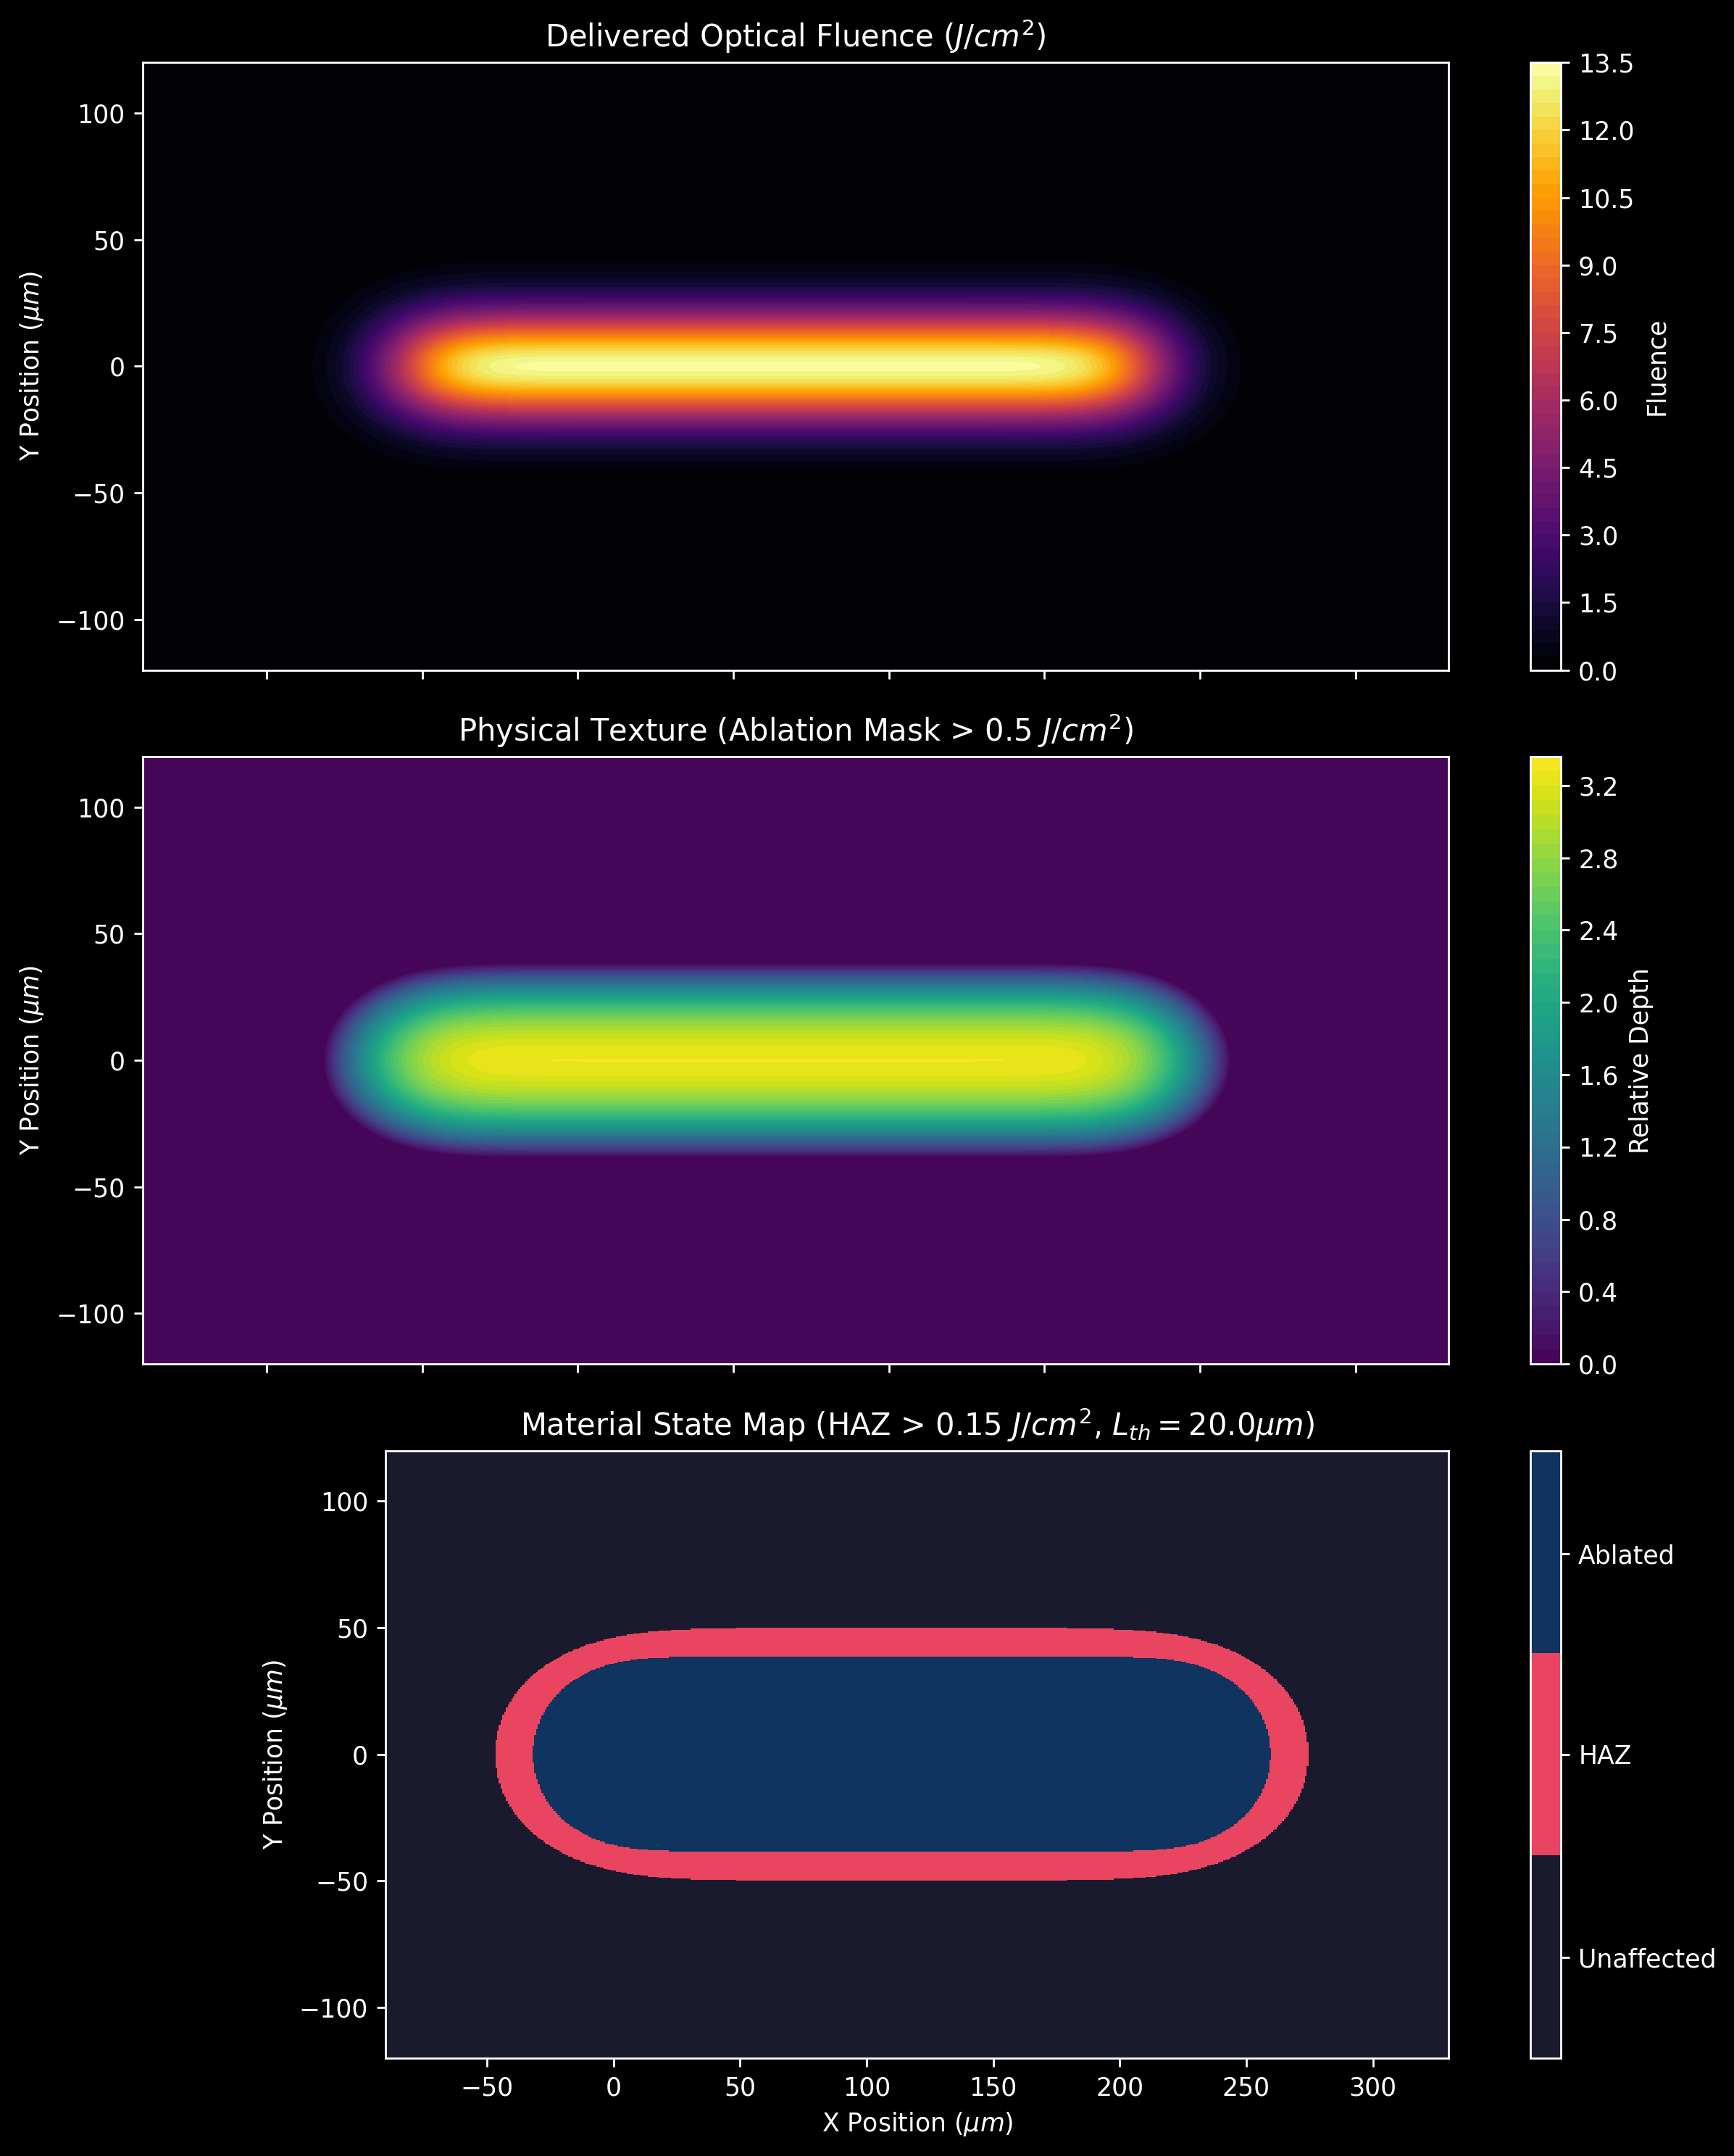

In [8]:
"""
Thermal-Diffusion Laser Ablation and HAZ Simulator.

This module models both the physical material removal (ablation) and the
surrounding Heat-Affected Zone (HAZ) for a scanning Gaussian laser beam.
It uses NumPy for vectorized optical energy mapping and SciPy to simulate
thermal diffusion via spatial convolution.

Installation requirements for Colab:
!uv pip install numpy matplotlib scipy
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

# --- CONTROL KNOBS ---
PULSE_ENERGY = 60e-6         # Joules (J)
SPOT_RADIUS = 30e-6          # Beam waist w0 (m)
F_THRESHOLD = 0.5            # Ablation threshold (J/cm^2)
F_HAZ = 0.15                 # HAZ threshold (J/cm^2) - Energy required to alter microstructure
PULSE_COUNT = 20             # Total number of pulses
OVERLAP_RATIO = 0.8          # Fractional overlap (0.0 to 1.0)
RESOLUTION = 600             # Grid points along each axis

# Thermal Physics Parameters
THERMAL_DIFFUSIVITY = 1.0e-5 # D for typical steel/titanium alloys (m^2/s)
COOLING_TIME = 1.0e-5        # Effective time for lateral heat spread (s)
# ---------------------

def simulate_thermal_ablation() -> None:
    """
    Simulate the laser scan, apply ablation masks, and calculate thermal diffusion.

    This function computes the optical fluence, extracts the residual heat,
    simulates thermal diffusion using a Gaussian filter, and renders a
    categorical map of the Unaffected, HAZ, and Ablated zones natively in Colab.
    """
    # 1. Coordinate Setup & Conversions
    f_th_si = F_THRESHOLD * 1e4
    f_haz_si = F_HAZ * 1e4

    spacing = 2 * SPOT_RADIUS * (1 - OVERLAP_RATIO)
    x_range = np.linspace(-3 * SPOT_RADIUS, PULSE_COUNT * spacing + 3 * SPOT_RADIUS, RESOLUTION)
    y_range = np.linspace(-4 * SPOT_RADIUS, 4 * SPOT_RADIUS, RESOLUTION)
    x_grid, y_grid = np.meshgrid(x_range, y_range)

    # Calculate physical pixel size for thermal diffusion scaling
    dx_m = (x_range[-1] - x_range[0]) / RESOLUTION

    # 2. Vectorized Optical Fluence Accumulation
    peak_f = (2 * PULSE_ENERGY) / (np.pi * SPOT_RADIUS**2)
    x_positions = np.arange(PULSE_COUNT) * spacing

    dx = x_grid[np.newaxis, :, :] - x_positions[:, np.newaxis, np.newaxis]
    dy = y_grid[np.newaxis, :, :]
    r_sq = dx**2 + dy**2

    optical_fluence = np.sum(peak_f * np.exp(-2 * r_sq / SPOT_RADIUS**2), axis=0)

    # 3. Ablation Physics
    ablation_mask = optical_fluence >= f_th_si
    effective_texture = np.zeros_like(optical_fluence)
    effective_texture[ablation_mask] = np.log(optical_fluence[ablation_mask] / f_th_si)

    # 4. Thermal Diffusion Physics
    # Energy that causes ablation is removed via plasma ejection.
    # We cap the heat source at F_th to represent the residual heat entering the bulk.
    residual_heat_source = np.clip(optical_fluence, a_min=0, a_max=f_th_si)

    # Calculate Thermal Diffusion Length (L_th)
    l_th = np.sqrt(4 * THERMAL_DIFFUSIVITY * COOLING_TIME)

    # Convert L_th to pixels for the Gaussian filter
    sigma_pixels = l_th / dx_m

    # Simulate heat diffusion
    diffused_thermal_field = gaussian_filter(residual_heat_source, sigma=sigma_pixels)

    # 5. Categorical Zone Mapping
    # 0 = Unaffected, 1 = HAZ, 2 = Ablated
    zone_map = np.zeros_like(optical_fluence)
    zone_map[diffused_thermal_field >= f_haz_si] = 1
    zone_map[ablation_mask] = 2  # Ablation overwrites HAZ

    # 6. Plotting Configuration
    plt.rcParams['figure.dpi'] = 250
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Top Plot: Optical Energy
    im1 = ax1.contourf(x_grid * 1e6, y_grid * 1e6, optical_fluence / 1e4, levels=50, cmap='inferno')
    ax1.set_title('Delivered Optical Fluence ($J/cm^2$)')
    ax1.set_ylabel('Y Position ($\mu m$)')
    fig.colorbar(im1, ax=ax1, label='Fluence')

    # Middle Plot: Physical Ablation
    im2 = ax2.contourf(x_grid * 1e6, y_grid * 1e6, effective_texture, levels=50, cmap='viridis')
    ax2.set_title(f'Physical Texture (Ablation Mask > {F_THRESHOLD} $J/cm^2$)')
    ax2.set_ylabel('Y Position ($\mu m$)')
    fig.colorbar(im2, ax=ax2, label='Relative Depth')

    # Bottom Plot: HAZ Categorical Map
    cmap_zones = ListedColormap(['#1a1a2e', '#e94560', '#0f3460'])
    im3 = ax3.imshow(zone_map, extent=[x_range[0]*1e6, x_range[-1]*1e6, y_range[0]*1e6, y_range[-1]*1e6],
                     origin='lower', cmap=cmap_zones, interpolation='none')
    ax3.set_title(f'Material State Map (HAZ > {F_HAZ} $J/cm^2$, $L_{{th}} = {l_th*1e6:.1f} \mu m$)')
    ax3.set_xlabel('X Position ($\mu m$)')
    ax3.set_ylabel('Y Position ($\mu m$)')

    # Custom legend for the categorical map
    cbar3 = fig.colorbar(im3, ax=ax3, ticks=[0.33, 1, 1.66])
    cbar3.ax.set_yticklabels(['Unaffected', 'HAZ', 'Ablated'])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_thermal_ablation()

<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_706/678492188.py:69: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Y Position ($\mu m$)')
/tmp/ipykernel_706/678492188.py:75: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('X Position ($\mu m$)')
/tmp/ipykernel_706/678492188.py:76: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Y Position ($\mu m$)')


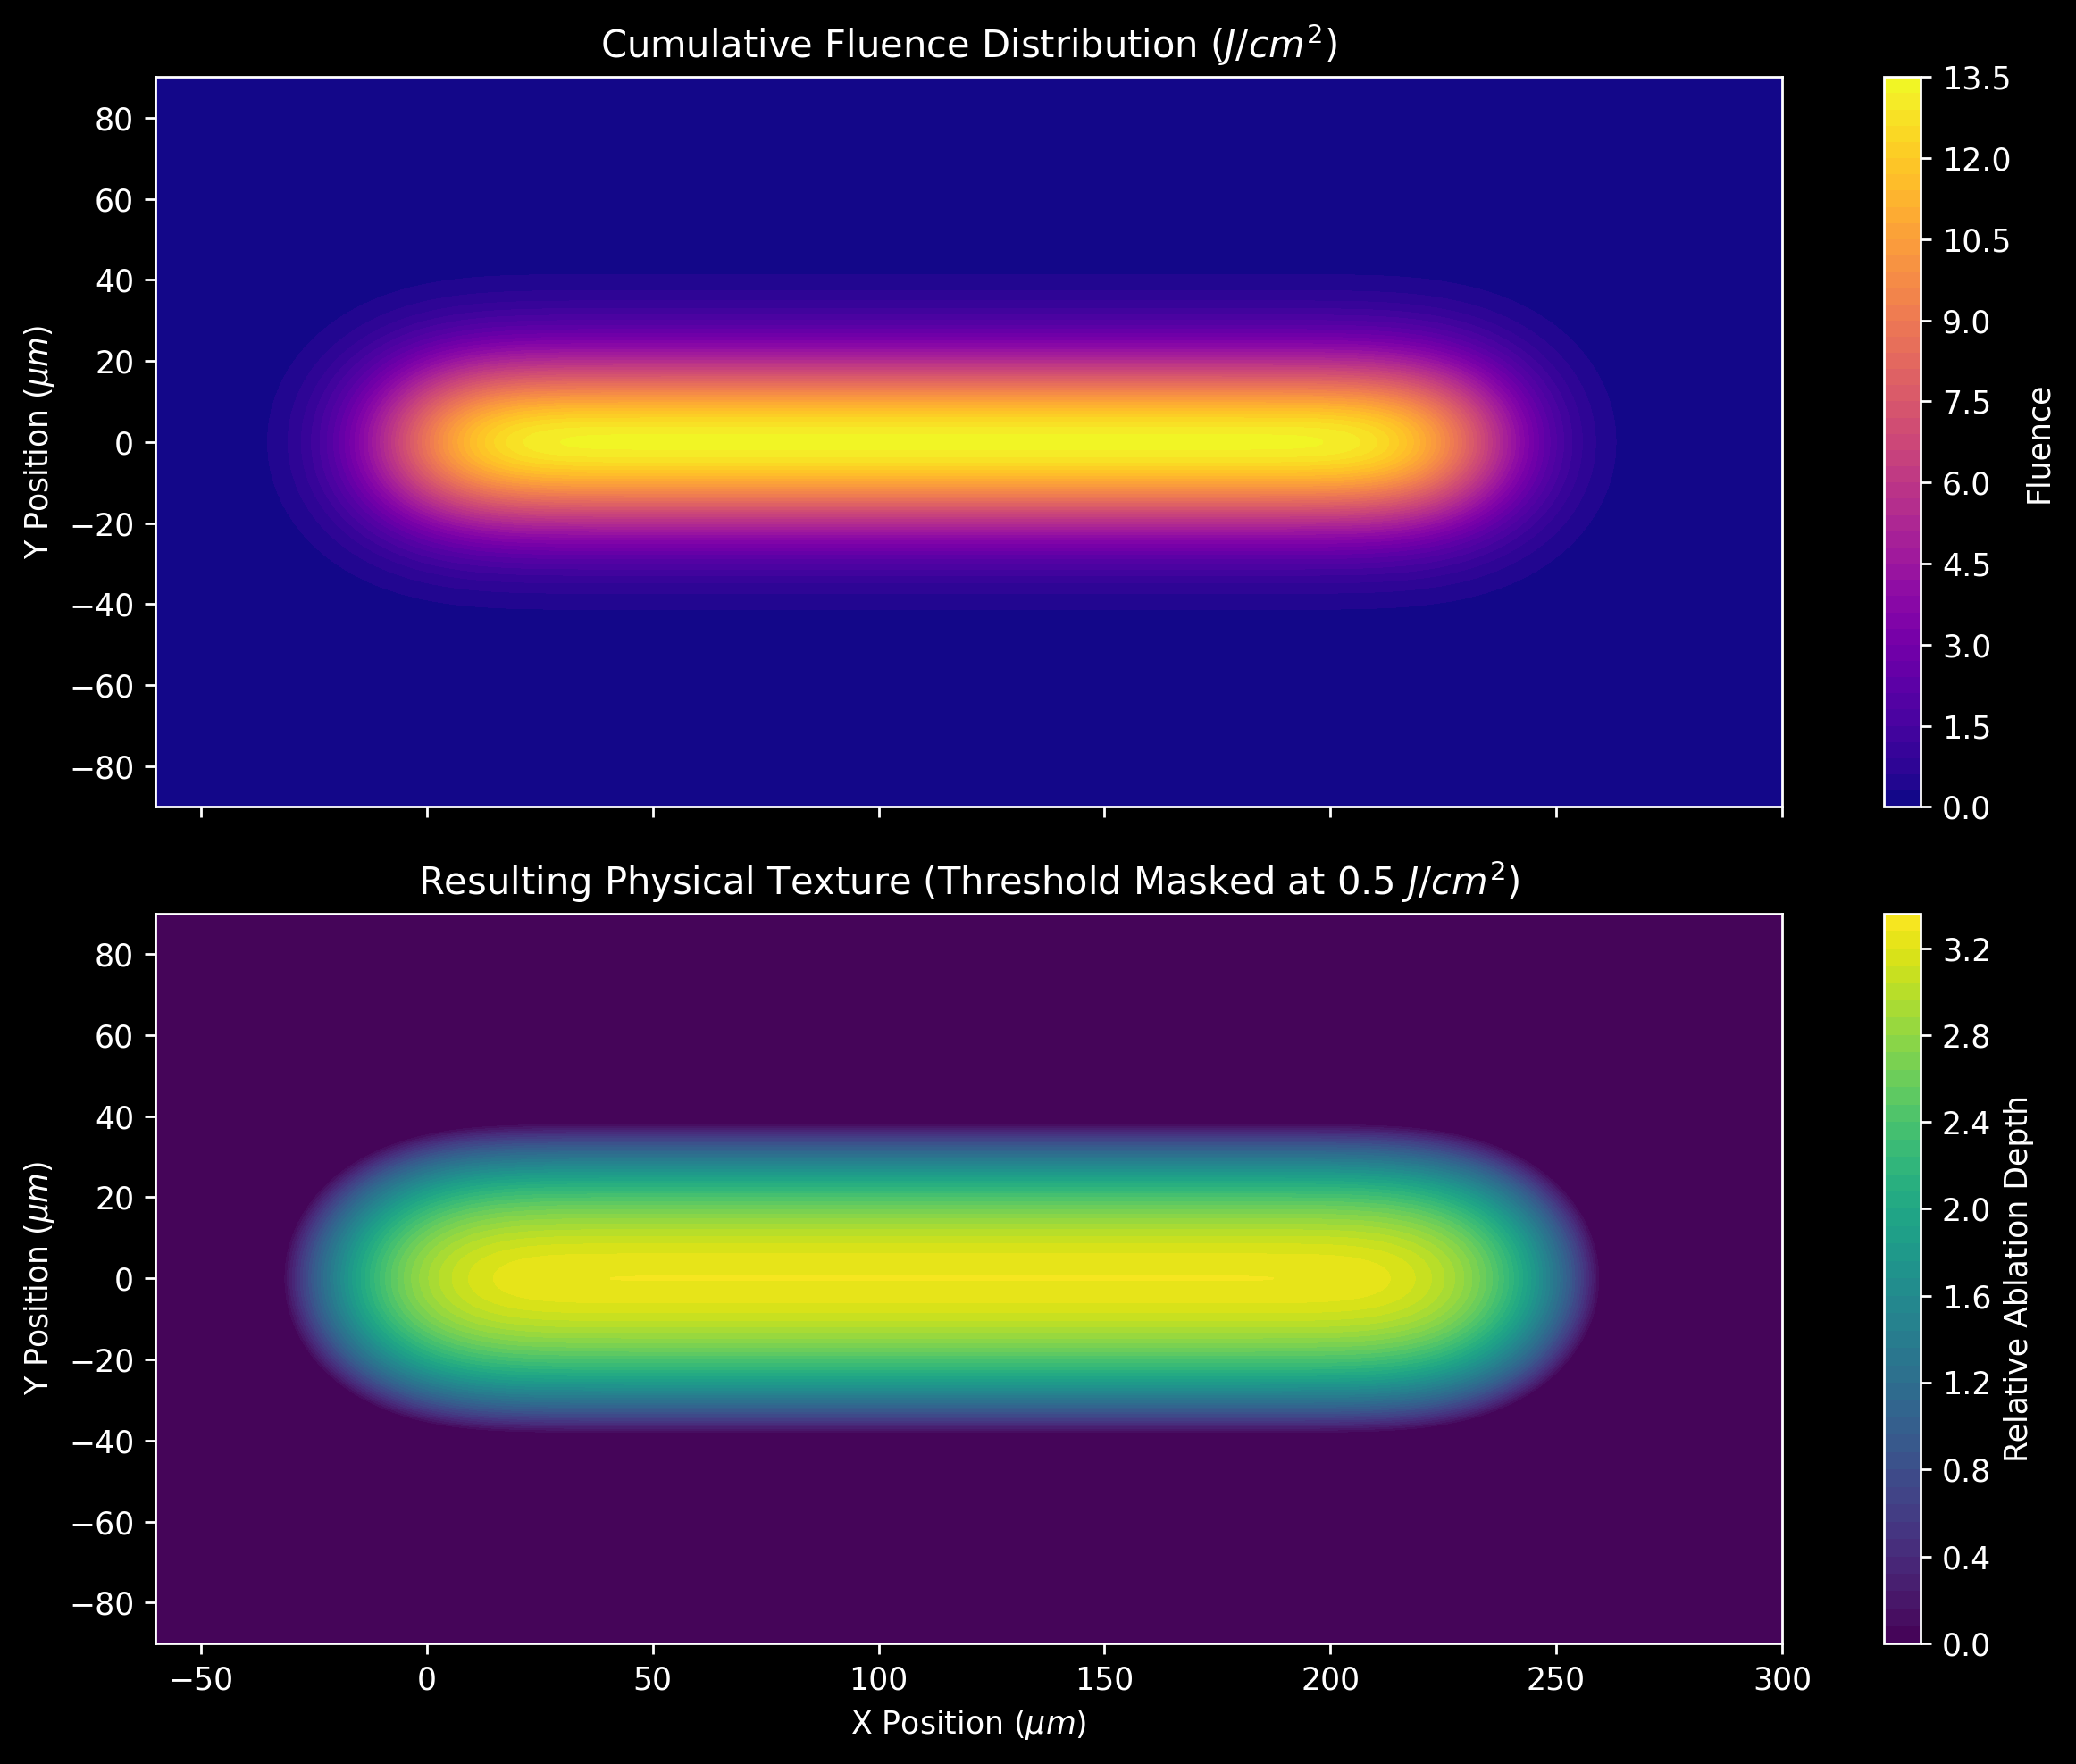

In [7]:
"""
Threshold-Masked Laser Ablation Simulator.

This module calculates the physical material removal (ablation depth)
by applying a material-specific threshold to a scanning Gaussian beam.
It is optimized using NumPy vectorization for High Performance Computing.

Installation requirements for Colab (if not already present):
!uv pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
PULSE_ENERGY = 60e-6         # Joules (J)
SPOT_RADIUS = 30e-6          # Beam waist w0 (m)
F_THRESHOLD = 0.5            # Ablation threshold in J/cm^2 (typical for Ti/Steel)
PULSE_COUNT = 20             # Total number of pulses in the scan line
OVERLAP_RATIO = 0.8          # Fractional overlap (0.0 to 1.0)
RESOLUTION = 600             # Grid points along each axis
# ---------------------

def calculate_ablation_profile() -> None:
    """
    Simulate the laser scan and apply the ablation threshold mask.

    This function generates a spatial grid, computes the cumulative
    fluence using vectorized broadcasting, applies a threshold mask,
    and renders the result natively in the Colab output.
    """
    # Convert Threshold from J/cm^2 to J/m^2 for SI consistency
    f_th_si = F_THRESHOLD * 1e4

    spacing = 2 * SPOT_RADIUS * (1 - OVERLAP_RATIO)
    x_range = np.linspace(-2 * SPOT_RADIUS, PULSE_COUNT * spacing + 2 * SPOT_RADIUS, RESOLUTION)
    y_range = np.linspace(-3 * SPOT_RADIUS, 3 * SPOT_RADIUS, RESOLUTION)
    x_grid, y_grid = np.meshgrid(x_range, y_range)

    peak_f = (2 * PULSE_ENERGY) / (np.pi * SPOT_RADIUS**2)

    # HPC Optimization: Vectorized Fluence Accumulation
    # Create an array of all pulse positions
    x_positions = np.arange(PULSE_COUNT) * spacing

    # Broadcast grid and pulse positions to a 3D volume (Pulses, Y, X)
    # This eliminates the 'for' loop entirely
    dx = x_grid[np.newaxis, :, :] - x_positions[:, np.newaxis, np.newaxis]
    dy = y_grid[np.newaxis, :, :]
    r_sq = dx**2 + dy**2

    # Calculate fluence for all pulses and sum along the pulse axis (axis=0)
    total_fluence = np.sum(peak_f * np.exp(-2 * r_sq / SPOT_RADIUS**2), axis=0)

    # Apply Threshold Masking
    ablation_mask = total_fluence >= f_th_si

    # Suppress log(0) warnings by restricting the calculation to the mask
    effective_texture = np.zeros_like(total_fluence)
    effective_texture[ablation_mask] = np.log(total_fluence[ablation_mask] / f_th_si)

    # Plotting Configuration
    plt.rcParams['figure.dpi'] = 250
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Top Plot: Total Energy Delivered
    im1 = ax1.contourf(x_grid * 1e6, y_grid * 1e6, total_fluence / 1e4, levels=50, cmap='plasma')
    ax1.set_title('Cumulative Fluence Distribution ($J/cm^2$)')
    ax1.set_ylabel('Y Position ($\mu m$)')
    fig.colorbar(im1, ax=ax1, label='Fluence')

    # Bottom Plot: Resulting Physical Texture (Ablated Zone)
    im2 = ax2.contourf(x_grid * 1e6, y_grid * 1e6, effective_texture, levels=50, cmap='viridis')
    ax2.set_title(f'Resulting Physical Texture (Threshold Masked at {F_THRESHOLD} $J/cm^2$)')
    ax2.set_xlabel('X Position ($\mu m$)')
    ax2.set_ylabel('Y Position ($\mu m$)')
    fig.colorbar(im2, ax=ax2, label='Relative Ablation Depth')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    calculate_ablation_profile()

Installing required libraries (svglib, reportlab)...
Please upload your pattern (PNG, JPEG, or SVG).


Saving IBM_logo.svg to IBM_logo (1).svg


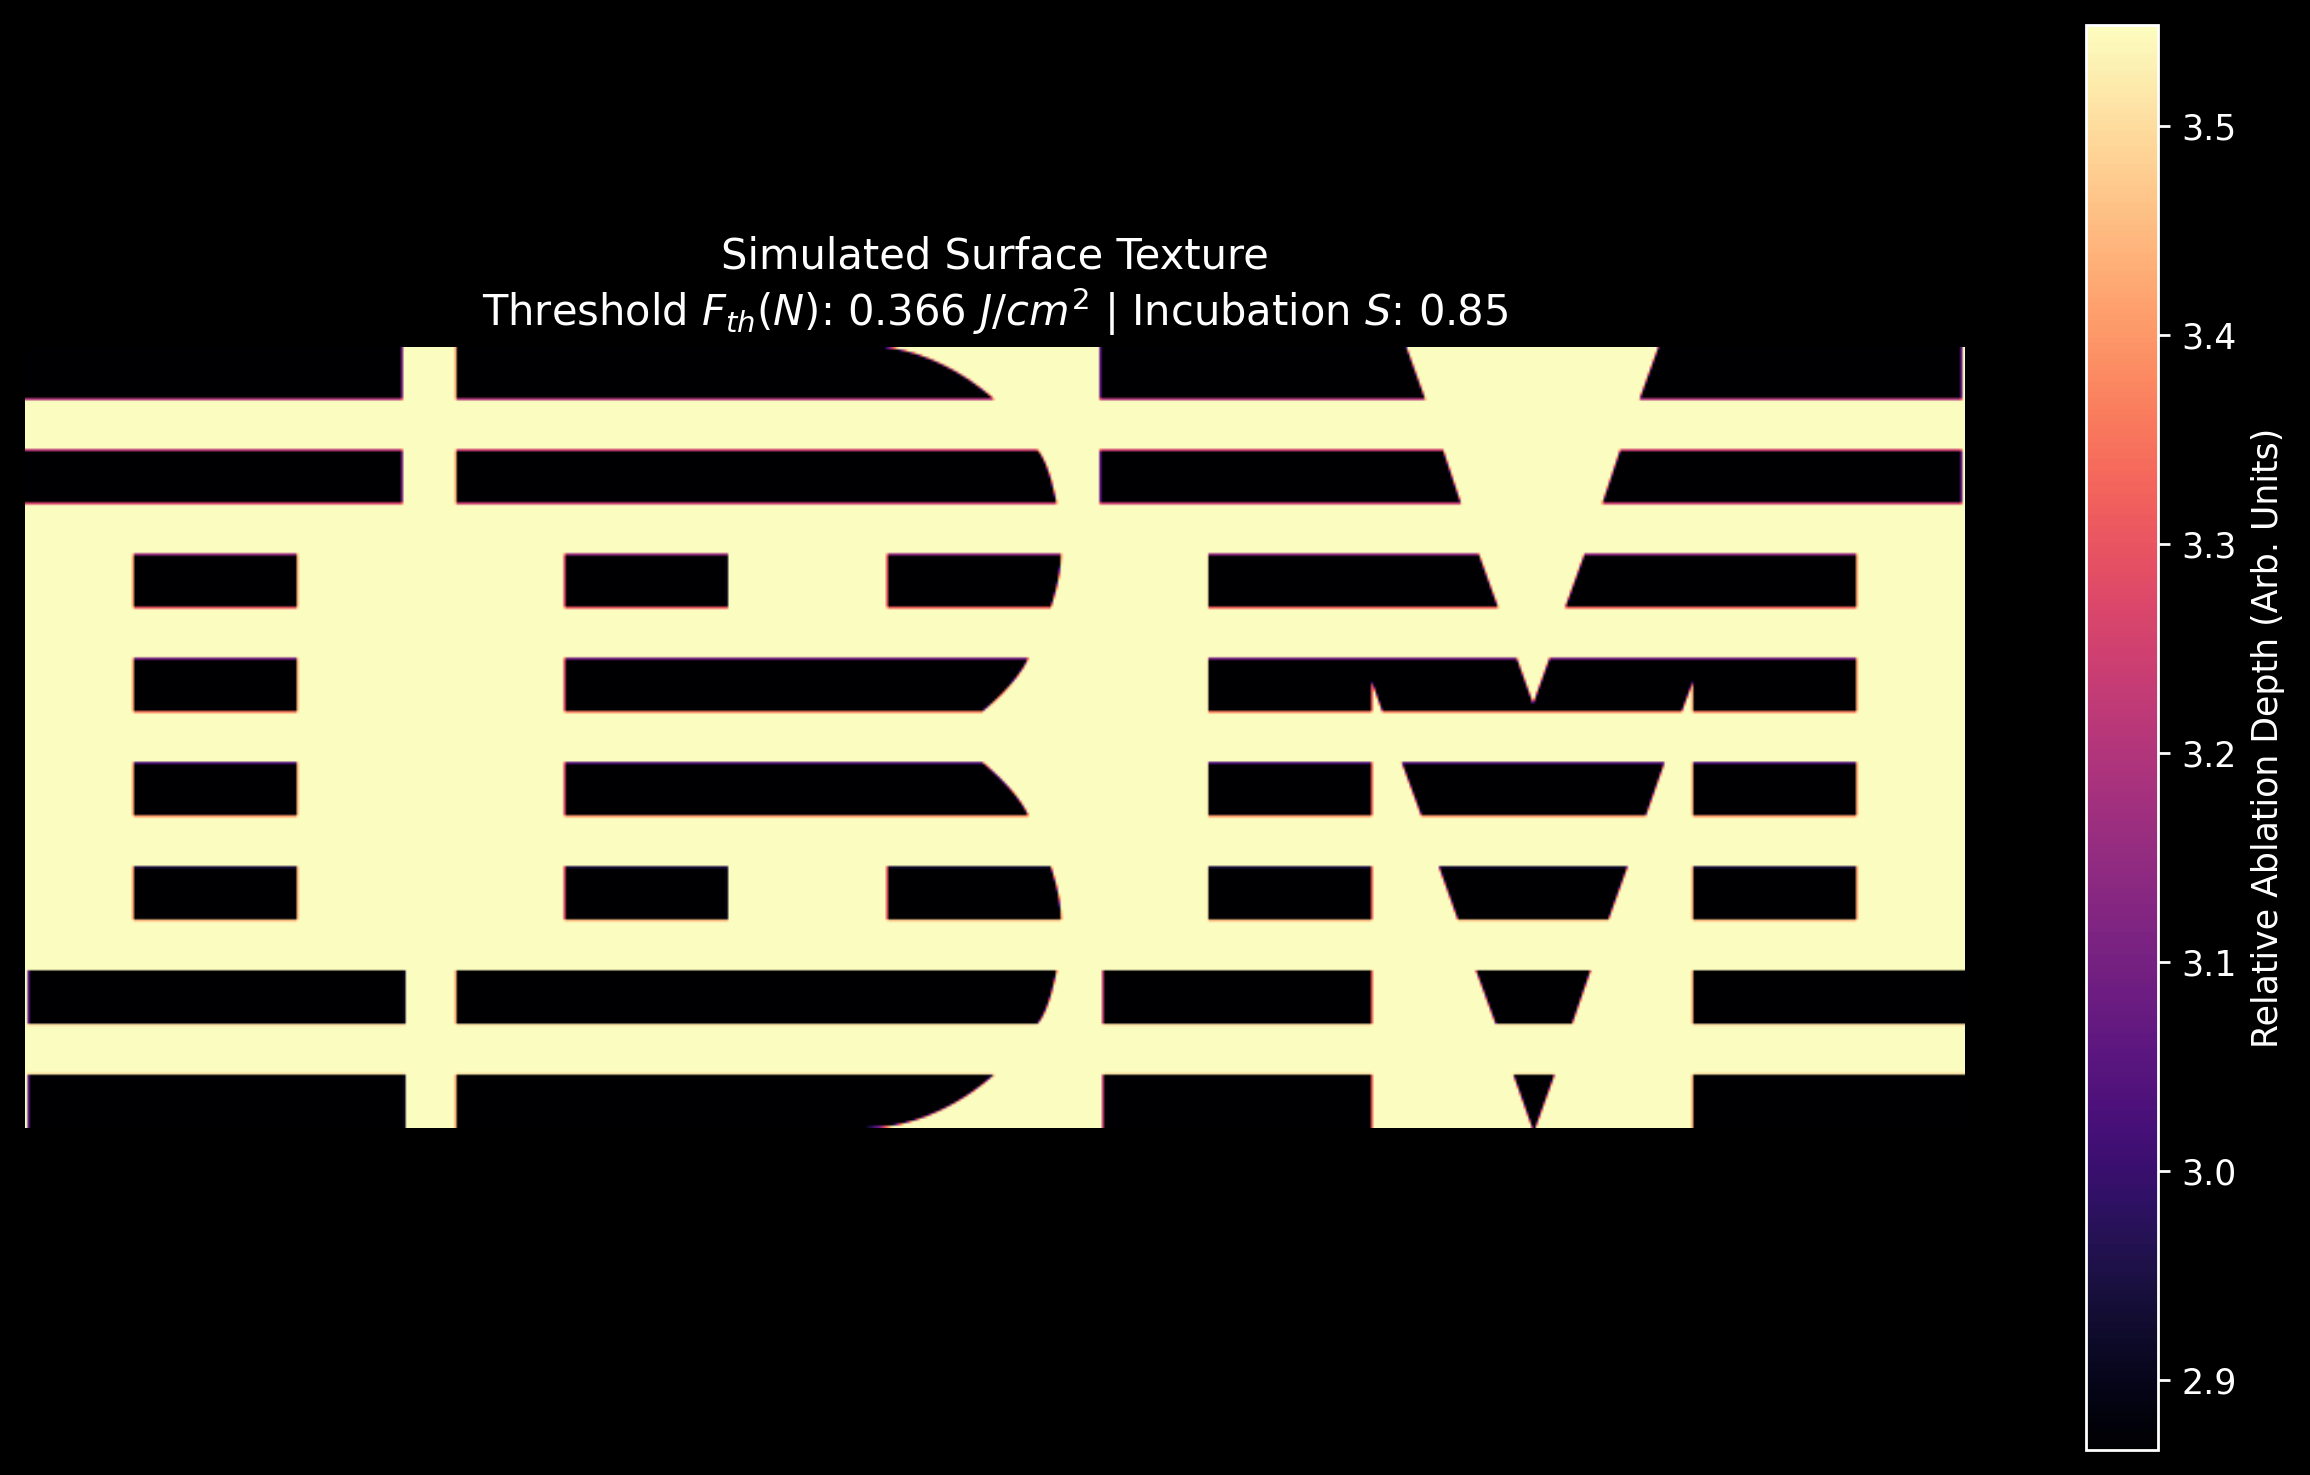

In [6]:
"""
Multi-Format Image-Driven Laser Ablation Simulator.

This script simulates physical laser texturing on a metal surface.
It supports the upload of PNG, JPEG, and SVG files, automatically
rasterizing vector graphics before computing the fluence map.
"""

import io
import os
import sys
import subprocess
import tempfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- DEPENDENCY MANAGEMENT ---
def install_dependencies():
    """Install required vector processing libraries via pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "svglib", "reportlab", "pillow"])

try:
    from svglib.svglib import svg2rlg
    from reportlab.graphics import renderPM
except ImportError:
    print("Installing required libraries (svglib, reportlab)...")
    install_dependencies()
    from svglib.svglib import svg2rlg
    from reportlab.graphics import renderPM

try:
    from google.colab import files
    COLAB_ENV = True
except ImportError:
    COLAB_ENV = False

# --- CONTROL KNOBS ---
PULSE_ENERGY = 80e-6          # Energy per pulse in Joules (J)
SPOT_RADIUS = 20e-6           # Beam waist (w0) in meters (m)
F_TH_1 = 0.55                 # Single-shot threshold in J/cm^2
S_COEFF = 0.85                # Incubation coefficient (typically 0.6 - 0.9)
OVERLAP_N = 15                # Average number of pulses per spot
# ---------------------

def process_svg_bytes(image_bytes):
    """
    Convert SVG byte data into a rasterized grayscale PIL Image.

    Parameters:
        image_bytes: Raw byte string of the uploaded SVG file.

    Returns:
        A PIL.Image object in grayscale ('L') mode.
    """
    # svglib requires a file path to parse the XML structure
    with tempfile.NamedTemporaryFile(delete=False, suffix='.svg') as temp_svg:
        temp_svg.write(image_bytes)
        temp_svg_path = temp_svg.name

    try:
        # Convert SVG to ReportLab Graphics (RLG) drawing
        drawing = svg2rlg(temp_svg_path)
        # Render RLG drawing to a PNG byte string
        png_data = renderPM.drawToString(drawing, fmt='PNG')
        img = Image.open(io.BytesIO(png_data)).convert('L')
    finally:
        # Ensure temporary file is cleaned up from Colab storage
        os.remove(temp_svg_path)

    return img

def get_image_data():
    """Prompt user for file upload and return a grayscale normalized array."""
    if not COLAB_ENV:
        raise EnvironmentError("This script requires a Google Colab environment for file uploads.")

    print("Please upload your pattern (PNG, JPEG, or SVG).")
    uploaded = files.upload()

    if not uploaded:
        return None

    file_name = list(uploaded.keys())[0]
    image_bytes = uploaded[file_name]

    # Conditional routing based on file format
    if file_name.lower().endswith('.svg'):
        img = process_svg_bytes(image_bytes)
    else:
        img = Image.open(io.BytesIO(image_bytes)).convert('L')

    return np.array(img) / 255.0

def simulate_image_texturing():
    """Process the uploaded image through the ablation physics model."""
    intensity_map = get_image_data()

    if intensity_map is None:
        print("No image provided. Simulation aborted.")
        return

    # 1. Calculate Incubation-Adjusted Threshold
    f_th_n = F_TH_1 * (OVERLAP_N**(S_COEFF - 1))
    f_th_si = f_th_n * 1e4  # Convert J/cm^2 to J/m^2 for SI consistency

    # 2. Calculate Laser Peak Fluence
    f0 = (2 * PULSE_ENERGY) / (np.pi * SPOT_RADIUS**2)

    # 3. Apply Local Fluence Scaling
    local_fluence = intensity_map * f0

    # 4. Calculate Ablation Depth (Logarithmic Law)
    ablation_depth = np.zeros_like(local_fluence)
    active_mask = local_fluence > f_th_si

    ablation_depth[active_mask] = np.log(local_fluence[active_mask] / f_th_si)

    # Rendering Configuration
    plt.rcParams['figure.dpi'] = 250
    plt.style.use('dark_background')

    fig, ax = plt.subplots(figsize=(10, 6))

    img_plot = ax.imshow(ablation_depth, cmap='magma', interpolation='bilinear')

    cbar = fig.colorbar(img_plot, ax=ax)
    cbar.set_label('Relative Ablation Depth (Arb. Units)')

    ax.set_title(f'Simulated Surface Texture\n'
                 f'Threshold $F_{{th}}(N)$: {f_th_n:.3f} $J/cm^2$ | '
                 f'Incubation $S$: {S_COEFF}')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_image_texturing()